<a href="https://colab.research.google.com/github/Fidyaayu/Project-1_House-Price-Prediction/blob/main/Proyek_1_House_Price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  **HOUSE PRICE PREDICTION**

# UNDERSTANDING


In [37]:
# Import library
import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

## Load Dataset

Dataset House Price dimuat dari file CSV dan menampilkan 5 data


In [38]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/MAGANG/minggu 2_proyek 1/House Price Prediction Dataset.csv')

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


##Dataset Overview

Dataset terdiri dari 2000 data dan 10 variabel. Terdapat 7 fitur numerik dan 3 fitur kategorikal. Variabel Price digunakan sebagai target untuk prediksi harga rumah

In [39]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


##Missing Value Analysis

Seluruh variabel memiliki nilai 0 sehingga dataset tidak memiliki data kosong

In [40]:
# Cek missing value seluruh variabel
missing_val = df.isnull().sum()
print(missing_val)

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [41]:
# Cek missing value yang tersembunyi, contoh: "Unknown", "NA"
df.isin(["Unknown", "NA", "N/A", "?", "None"]).sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [42]:
# Mengecek data duplikasi
df.duplicated().sum()

np.int64(0)

##Dataset Audit

*   Rata-rata luas rumah sekitar 2786 sqft
*   Rata-rata jumlah kamar tidur sekitar 3 kamar
*   Rata-rata kamar mandi sekitar 2–3 kamar mandi
*   Harga rumah memiliki rentang sekitar 50.000 hingga hampir 1.000.000
Hal ini menunjukkan bahwa dataset memiliki variasi karakteristik rumah yang cukup beragam.

In [43]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [44]:
df['Condition'].value_counts()

,count
Condition,
Fair,521
Excellent,511
Poor,507
Good,461


In [45]:
df['Location'].value_counts()

,count
Location,
Downtown,558
Urban,485
Suburban,483
Rural,474


In [46]:
df['Garage'].value_counts()

,count
Garage,
No,1038
Yes,962


## EDA (Eksplorasi Data Analysis)

Histogram menunjukkan bahwa harga rumah berada pada kisaran 50.000 hingga sekitar 1.000.000.

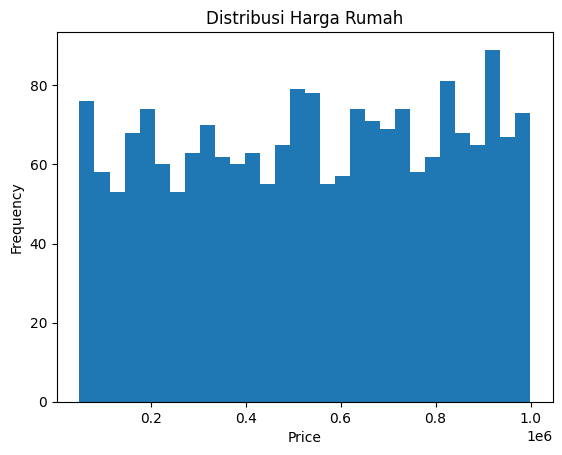

In [47]:
plt.hist(df['Price'], bins=30)
plt.title("Distribusi Harga Rumah")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

array([[<Axes: title={'center': 'Id'}>, <Axes: title={'center': 'Area'}>,
        <Axes: title={'center': 'Bedrooms'}>],
       [<Axes: title={'center': 'Bathrooms'}>,
        <Axes: title={'center': 'Floors'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'Price'}>, <Axes: >, <Axes: >]],
      dtype=object)

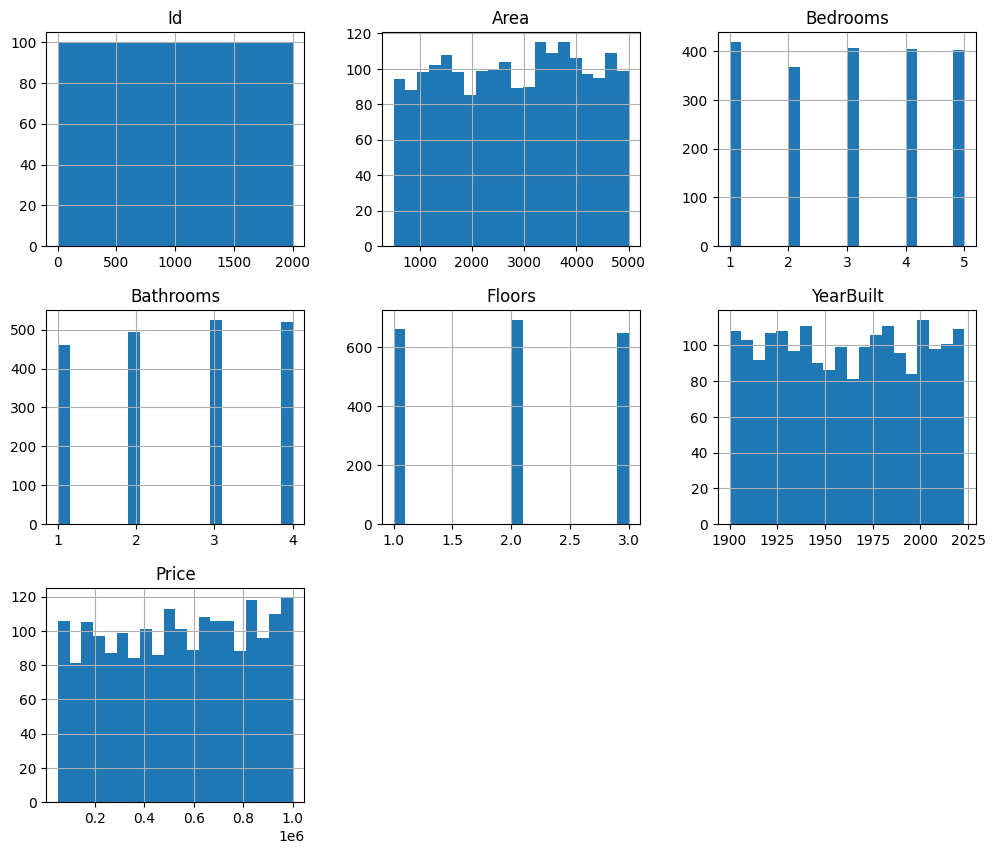

In [48]:
df.hist(figsize=(12,10), bins=20)

##Data PreProcessing

###Pembagian Data

In [49]:
from sklearn.model_selection import train_test_split

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [50]:
# Melihat jumlah data setelah di bagi
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 9)
(400, 9)
(1600,)
(400,)


###Encoding Fitur Kategorikal

In [51]:
# 1. Binary (Garage)
X_train['Garage'] = X_train['Garage'].map({'No': 0, 'Yes': 1})
X_test['Garage'] = X_test['Garage'].map({'No': 0, 'Yes': 1})

In [52]:
# 2. Ordinal/berurutan/tingkatan (Condition)
condition_mapping = {
    'Poor': 0,
    'Fair': 1,
    'Good': 2,
    'Excellent': 3
}
X_train['Condition'] = X_train['Condition'].map(condition_mapping)
X_test['Condition'] = X_test['Condition'].map(condition_mapping)

In [53]:
from sklearn.preprocessing import OneHotEncoder

# 3. Nominal (Location)
encoder = OneHotEncoder(drop='first', handle_unknown='ignore')

X_train_loc = encoder.fit_transform(X_train[['Location']])
X_test_loc = encoder.transform(X_test[['Location']])

# Ubah jadi DataFrame
loc_columns = encoder.get_feature_names_out(['Location'])

X_train_loc = pd.DataFrame(X_train_loc.toarray(), columns=loc_columns, index=X_train.index)
X_test_loc = pd.DataFrame(X_test_loc.toarray(), columns=loc_columns, index=X_test.index)

# Drop kolom lama + gabungkan
X_train = X_train.drop(columns=['Location'])
X_test = X_test.drop(columns=['Location'])

X_train = pd.concat([X_train, X_train_loc], axis=1)
X_test = pd.concat([X_test, X_test_loc], axis=1)

In [54]:
# Preview hasil akhir setelah di encoding
X_train.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Condition,Garage,Location_Rural,Location_Suburban,Location_Urban
968,969,4483,4,4,3,1933,3,0,0.0,0.0,1.0
240,241,1062,3,3,1,1970,2,0,0.0,0.0,0.0
819,820,1422,3,4,1,1993,2,1,0.0,0.0,1.0
692,693,2658,2,3,1,1972,0,1,1.0,0.0,0.0
420,421,3286,2,4,1,1981,3,1,1.0,0.0,0.0


In [55]:
# Cek hasil encoding spesifik
X_train['Garage'].value_counts()

,count
Garage,
0,841
1,759


In [56]:
# Cek hasil encoding spesifik
X_train['Condition'].value_counts()

,count
Condition,
1,423
0,410
3,400
2,367


In [57]:
X_train.filter(like='Location').head()

,Location_Rural,Location_Suburban,Location_Urban
968,0.0,0.0,1.0
240,0.0,0.0,0.0
819,0.0,0.0,1.0
692,1.0,0.0,0.0
420,1.0,0.0,0.0


###Scaling

In [58]:
# pastikan semua fitur numerik
X_train.dtypes

,0
Id,int64
Area,int64
Bedrooms,int64
Bathrooms,int64
Floors,int64
YearBuilt,int64
Condition,int64
Garage,int64
Location_Rural,float64
Location_Suburban,float64


In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [60]:
num_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
scaler = StandardScaler()

# FIT hanya di TRAIN
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# TRANSFORM di TEST
X_test[num_cols] = scaler.transform(X_test[num_cols])

# **ALGORITMA LINEAR REGRESSION**

##Import Library

Membuat objek model Linear Regression yang akan digunakan dalam proses pelatihan dan prediksi

In [61]:
# Inisialisasi model LR
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

##Prediksi

Model digunakan untuk memprediksi harga rumah pada data testing. Hasil prediksi ini nantinya dibandingkan dengan data asli

In [62]:
# Prediksi
y_pred = model.predict(X_test)

##Evaluasi Model

In [63]:
# Evaluasi Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 243076.62633879684
RMSE: 279977.7136307904
R2: -0.007566844144381246


In [64]:
df.corr(numeric_only=True)['Price'].sort_values(ascending=False)

,Price
Price,1.000000
Floors,0.055890
YearBuilt,0.004845
Area,0.001542
Bedrooms,-0.003471
Bathrooms,-0.015737
Id,-0.025643


In [65]:
# Cek struktur fitur
print(X_train.columns)
print(X_test.columns)

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Condition', 'Garage', 'Location_Rural', 'Location_Suburban',
       'Location_Urban'],
      dtype='object')
Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Condition', 'Garage', 'Location_Rural', 'Location_Suburban',
       'Location_Urban'],
      dtype='object')


##Visualisasi Model

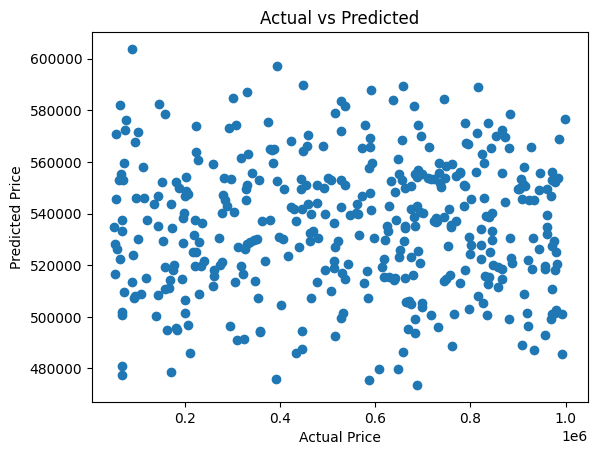

In [66]:
# Membandingkan Prediksi dan aktual

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [67]:
# Cek overfitting
y_train_pred = model.predict(X_train)

print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_pred))

Train R2: 0.00857065545486646
Test R2: -0.007566844144381246


# **ALGORITMA RANDOM FOREST**

Hasil eksperimen menunjukkan bahwa baik model linear (Linear regression) maupun non-linear (Random Forest) gagal mencapai performa yang memadai, yang mengindikasikan bahwa tidak adanya pola yang dapat dipelajari dalam data.

In [68]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

print("RF R2:", rf.score(X_test, y_test))

RF R2: -0.06073618405543213
